In [1]:
# =============================================================================
# CELL 1: IMPORTS AND SETUP
# =============================================================================
import pandas as pd
import numpy as np
import pyodbc
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 50)

def run_sql(query):
    with pyodbc.connect("DSN=Redshift_prod_new") as conn:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=conn)
        warnings.filterwarnings("default", category=UserWarning)
    return df

with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    conn.cursor().execute("SELECT 1").fetchone()
print("ODBC connection OK")

ODBC connection OK


In [2]:
# =============================================================================
# CELL 2: DATA FETCH
# =============================================================================

# --- RAGU individual inputs ---
ragu_df = run_sql("""
    SELECT r.account_number, r.lob, r.book_date,
           r.model_score, r.gross_loss_impact, r.gross_loss_ragu,
           r.ltv, r.apr, r.amt_financed, r.recovery_multiplier
    FROM sandbox.gl_ragu_individual r
    WHERE r.gross_loss_ragu IS NOT NULL
""")
ragu_df['book_date'] = pd.to_datetime(ragu_df['book_date'])
print(f"RAGU rows: {len(ragu_df):,}")

# --- Contract term ---
term_df = run_sql("""
    SELECT account_number, con_term
    FROM edwnpi.los_deal_current_fact
    WHERE con_term IS NOT NULL
""")
print(f"Term rows: {len(term_df):,}")

# --- Recovery multiplier (new model) ---
recovery_df = run_sql("""
    SELECT account_number
         , lob
         , con_date AS book_date
         , CASE
               WHEN lob IN ('KMX', 'ENT', 'FLD')
                   THEN 0.15 * (pred_t0_adj_impound * (1 - pred_depr_rate_std) ^ 2.3)
                      + 0.85 * (pred_t0_adj_no_impound * (1 - pred_depr_rate_std) ^ 2.3)
               ELSE 0.15 * (pred_t0_adj_impound * (1 - pred_depr_rate_std) ^ 2)
                  + 0.85 * (pred_t0_adj_no_impound * (1 - pred_depr_rate_std) ^ 2)
           END AS new_recovery_multiplier
    FROM sandbox.rds_rec_model_originations rec
    LEFT JOIN edwnpi.date_dim AS dd
              ON rec.con_date = dd.calendar_date
""")
recovery_df['book_date'] = pd.to_datetime(recovery_df['book_date'])
print(f"Recovery model rows: {len(recovery_df):,}")

# --- Actuals (chargeoff outcomes) ---
actuals_df = run_sql("""
    WITH all_accounts AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(proceeds) AS proceeds
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
        GROUP BY 1, 2
    ),
    chargeoffs AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(gross_loss_amt) AS gross_loss_amt,
               MAX(net_loss_amt) AS net_loss_amt
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
          AND account_life_cycle = 'CHARGEOFF'
        GROUP BY 1, 2
    )
    SELECT a.account_number,
           a.sp_book_date_quarter_vintage AS vintage,
           a.proceeds,
           COALESCE(co.gross_loss_amt, 0) AS gross_loss_amt,
           COALESCE(co.net_loss_amt, 0) AS net_loss_amt,
           CASE WHEN co.account_number IS NOT NULL THEN 1 ELSE 0 END AS is_chargeoff
    FROM all_accounts a
    LEFT JOIN chargeoffs co
        ON a.account_number = co.account_number
       AND a.sp_book_date_quarter_vintage = co.sp_book_date_quarter_vintage
""")
print(f"Actuals rows: {len(actuals_df):,}")
print(f"Vintage range: {actuals_df['vintage'].min()} to {actuals_df['vintage'].max()}")

RAGU rows: 818,180
Term rows: 1,582,901
Recovery model rows: 1,214,712
Actuals rows: 929,442
Vintage range: 2020 Q1 to 225 Q4


In [12]:
# =============================================================================
# CELL 3: MERGE, FILTER, AND COMPUTE DERIVED COLUMNS
# =============================================================================

V1_UL = 0.5
V1_UL_TO_MS = 0.02

BASELINES = {
    'AN':  {'ltv': 1.94, 'apr': 0.25},
    'FRN': {'ltv': 1.94, 'apr': 0.25},
    'STG': {'ltv': 1.94, 'apr': 0.25},
    'FLD': {'ltv': 1.45, 'apr': 0.235},
    'ENT': {'ltv': 1.45, 'apr': 0.235},
    'KMX': {'ltv': 1.59, 'apr': 0.25},
}

MATURITY_CUTOFF = '2023-12-31'
LTV_MIN, LTV_MAX = 1.00, 2.00

# --- Merge RAGU inputs with term data ---
ragu_with_term = ragu_df.merge(
    term_df[['account_number', 'con_term']].drop_duplicates(subset='account_number', keep='first'),
    on='account_number', how='left'
)

# --- Merge with recovery multiplier ---
nr = recovery_df[['account_number', 'new_recovery_multiplier']].drop_duplicates(
    subset='account_number', keep='first'
)

# --- Merge with actuals ---
merged = ragu_with_term.merge(
    actuals_df[['account_number', 'vintage', 'proceeds', 'gross_loss_amt',
                'net_loss_amt', 'is_chargeoff']],
    on='account_number', how='inner'
).merge(
    nr, on='account_number', how='left'
)

print(f"Pre-filter merged rows: {len(merged):,}")
print(f"Book date range: {merged['book_date'].min()} to {merged['book_date'].max()}")

# --- Maturity filter ---
merged = merged[merged['book_date'] <= MATURITY_CUTOFF].copy()
print(f"\nAfter maturity filter (<= {MATURITY_CUTOFF}): {len(merged):,} rows")
print(f"  Chargeoffs: {merged['is_chargeoff'].sum():,} ({merged['is_chargeoff'].mean():.1%})")

# --- Derived columns ---
merged['gross_loss_pct'] = merged['gross_loss_amt'] / merged['proceeds']
merged['cnl_pct'] = merged['net_loss_amt'] / merged['proceeds']
merged['recovery_pct'] = merged['gross_loss_pct'] - merged['cnl_pct']
merged['loss_multiplier'] = 1 - merged['gross_loss_impact'] * V1_UL_TO_MS / V1_UL
merged['baseline_apr'] = merged['lob'].map({k: v['apr'] for k, v in BASELINES.items()})

# --- Vintage year extraction ---
merged['vintage_year'] = merged['vintage'].str[:4].astype(int)

# --- LTV band flag for recovery analysis ---
merged['ltv_in_range'] = (merged['ltv'] >= LTV_MIN) & (merged['ltv'] < LTV_MAX)

print(f"\nVintage year distribution:")
print(merged.groupby('vintage_year').agg(
    n_loans=('account_number', 'count'),
    n_chargeoffs=('is_chargeoff', 'sum'),
    chargeoff_rate=('is_chargeoff', 'mean')
).to_string())

print(f"\nRecovery multiplier coverage: {merged['new_recovery_multiplier'].notna().sum():,} / {len(merged):,}")
print(f"LTV in [100%, 200%): {merged['ltv_in_range'].sum():,} ({merged['ltv_in_range'].mean():.1%})")

Pre-filter merged rows: 805,967
Book date range: 2020-01-02 00:00:00 to 2026-06-30 00:00:00

After maturity filter (<= 2023-12-31): 449,826 rows
  Chargeoffs: 228,422 (50.8%)

Vintage year distribution:
              n_loans  n_chargeoffs  chargeoff_rate
vintage_year                                       
2020           130018         61716        0.474673
2021           137932         74558        0.540542
2022            93263         53655        0.575309
2023            88613         38493        0.434395

Recovery multiplier coverage: 448,264 / 449,826
LTV in [100%, 200%): 278,080 (61.8%)


In [13]:
# =============================================================================
# CELL 4: LEAVE-ONE-OUT VINTAGE SENSITIVITY ANALYSIS
# =============================================================================

def run_scenario(df, train_years, test_years=None, label=''):
    """
    Run OLS regressions on the given vintage years and optionally
    compute out-of-sample R-squared on the held-out years.

    Returns dict with GL mult, APR mult, F, beta_ltv, R-squareds.
    """
    train = df[df['vintage_year'].isin(train_years)].copy()

    # --- Gross Loss OLS: gross_loss_pct ~ model_score + loss_multiplier + apr ---
    gl_valid = train[
        train['model_score'].notna() &
        train['loss_multiplier'].notna() &
        train['apr'].notna() &
        train['gross_loss_pct'].notna()
    ]

    X_gl = gl_valid[['model_score', 'loss_multiplier', 'apr']].values
    y_gl = gl_valid['gross_loss_pct'].values

    lr_gl = LinearRegression().fit(X_gl, y_gl)
    coef_ms, coef_lm, coef_apr = lr_gl.coef_
    gl_r2 = r2_score(y_gl, lr_gl.predict(X_gl))

    gl_mult = abs(coef_lm / coef_ms)
    apr_mult = abs(coef_apr / coef_ms) / 100

    # --- Recovery/LTV OLS: recovery_pct ~ R + LTV (chargeoffs, LTV in range) ---
    co_train = train[
        (train['is_chargeoff'] == 1) &
        train['ltv_in_range'] &
        train['new_recovery_multiplier'].notna()
    ]

    X_rec = co_train[['new_recovery_multiplier', 'ltv']].values
    y_rec = co_train['recovery_pct'].values

    lr_rec = LinearRegression().fit(X_rec, y_rec)
    coef_R, coef_LTV = lr_rec.coef_
    rec_r2 = r2_score(y_rec, lr_rec.predict(X_rec))

    F_empirical = coef_R
    beta_ltv = abs(coef_LTV) / coef_R

    result = {
        'label': label,
        'train_years': train_years,
        'n_loans_gl': len(gl_valid),
        'n_chargeoffs_rec': len(co_train),
        'coef_ms': coef_ms,
        'coef_lm': coef_lm,
        'coef_apr': coef_apr,
        'gl_mult': gl_mult,
        'apr_mult': apr_mult,
        'gl_r2': gl_r2,
        'F_empirical': F_empirical,
        'beta_ltv': beta_ltv,
        'coef_R': coef_R,
        'coef_LTV': coef_LTV,
        'rec_r2': rec_r2,
        'oos_gl_r2': np.nan,
        'oos_rec_r2': np.nan,
    }

    # --- Out-of-sample evaluation ---
    if test_years:
        test = df[df['vintage_year'].isin(test_years)].copy()

        # GL out-of-sample
        gl_test = test[
            test['model_score'].notna() &
            test['loss_multiplier'].notna() &
            test['apr'].notna() &
            test['gross_loss_pct'].notna()
        ]
        if len(gl_test) > 0:
            X_test = gl_test[['model_score', 'loss_multiplier', 'apr']].values
            y_test = gl_test['gross_loss_pct'].values
            result['oos_gl_r2'] = r2_score(y_test, lr_gl.predict(X_test))

        # Recovery out-of-sample
        co_test = test[
            (test['is_chargeoff'] == 1) &
            test['ltv_in_range'] &
            test['new_recovery_multiplier'].notna()
        ]
        if len(co_test) > 0:
            X_rec_test = co_test[['new_recovery_multiplier', 'ltv']].values
            y_rec_test = co_test['recovery_pct'].values
            result['oos_rec_r2'] = r2_score(y_rec_test, lr_rec.predict(X_rec_test))

    return result


# --- Define scenarios ---
ALL_YEARS = [2020, 2021, 2022, 2023]

scenarios = [
    {'label': 'Full (2020-2023)',  'train': ALL_YEARS,            'test': None},
    {'label': 'Excl 2021',         'train': [2020, 2022, 2023],   'test': [2021]},
    {'label': 'Excl 2020',         'train': [2021, 2022, 2023],   'test': [2020]},
    {'label': 'Excl 2022',         'train': [2020, 2021, 2023],   'test': [2022]},
    {'label': 'Excl 2023',         'train': [2020, 2021, 2022],   'test': [2023]},
]

results = []
for s in scenarios:
    res = run_scenario(merged, train_years=s['train'], test_years=s['test'], label=s['label'])
    results.append(res)

results_df = pd.DataFrame(results)
print("Scenarios computed successfully.")
print(f"Rows per scenario: {results_df['n_loans_gl'].tolist()}")

Scenarios computed successfully.
Rows per scenario: [449826, 311894, 319808, 356563, 361213]


In [14]:
# =============================================================================
# CELL 5: RESULTS SUMMARY AND INTERPRETATION
# =============================================================================

# Combine F, beta_ltv, and GL_mult into a single LTV coefficient per scenario
# LTV coef = beta_ltv * F * GL_mult (the multiplier on (baseline_LTV - actual_LTV))
results_df['ltv_coef'] = results_df['beta_ltv'] * results_df['F_empirical'] * results_df['gl_mult']

print("=" * 110)
print("LEAVE-ONE-OUT VINTAGE SENSITIVITY: COEFFICIENT STABILITY")
print("=" * 110)

print(f"\n{'Scenario':<20} {'N (GL)':<10} {'N (Rec)':<10} {'GL mult':>10} {'APR mult':>10} "
      f"{'LTV coef':>10} {'GL R²':>8} {'Rec R²':>8} {'OOS GL R²':>10} {'OOS Rec R²':>11}")
print("-" * 110)

for _, row in results_df.iterrows():
    oos_gl = f"{row['oos_gl_r2']:.5f}" if not np.isnan(row['oos_gl_r2']) else '--'
    oos_rec = f"{row['oos_rec_r2']:.5f}" if not np.isnan(row['oos_rec_r2']) else '--'
    print(f"{row['label']:<20} {row['n_loans_gl']:<10,} {row['n_chargeoffs_rec']:<10,} "
          f"{row['gl_mult']:>10.2f} {row['apr_mult']:>10.4f} "
          f"{row['ltv_coef']:>10.4f} "
          f"{row['gl_r2']:>8.5f} {row['rec_r2']:>8.5f} "
          f"{oos_gl:>10} {oos_rec:>11}")

# --- Stability metrics (CV across leave-one-out scenarios only) ---
loo = results_df[results_df['label'] != 'Full (2020-2023)'].copy()
full_row = results_df[results_df['label'] == 'Full (2020-2023)'].iloc[0]

print(f"\n{'=' * 110}")
print("COEFFICIENT STABILITY METRICS (across 4 leave-one-out scenarios)")
print("=" * 110)

metrics = ['gl_mult', 'apr_mult', 'ltv_coef']
metric_labels = ['GL multiplier', 'APR multiplier', 'LTV coefficient']

print(f"\n{'Coefficient':<20} {'Full-sample':>12} {'LOO Mean':>10} {'LOO Std':>10} {'LOO CV':>8} "
      f"{'LOO Min':>10} {'LOO Max':>10} {'Max % dev':>10}")
print("-" * 95)

for metric, label in zip(metrics, metric_labels):
    full_val = full_row[metric]
    loo_mean = loo[metric].mean()
    loo_std = loo[metric].std()
    loo_cv = loo_std / loo_mean if loo_mean != 0 else np.nan
    loo_min = loo[metric].min()
    loo_max = loo[metric].max()
    max_pct_dev = max(abs(loo_min - full_val), abs(loo_max - full_val)) / abs(full_val) * 100
    print(f"{label:<20} {full_val:>12.4f} {loo_mean:>10.4f} {loo_std:>10.4f} {loo_cv:>8.3f} "
          f"{loo_min:>10.4f} {loo_max:>10.4f} {max_pct_dev:>9.1f}%")

# --- Interpretation ---
print(f"\n{'=' * 110}")
print("INTERPRETATION")
print("=" * 110)

for metric, label in zip(metrics, metric_labels):
    full_val = full_row[metric]
    max_dev = max(abs(loo[metric].min() - full_val),
                  abs(loo[metric].max() - full_val)) / abs(full_val) * 100
    stability = 'STABLE' if max_dev < 10 else ('MODERATE' if max_dev < 25 else 'UNSTABLE')
    print(f"  {label:<20}: max deviation = {max_dev:.1f}% from full-sample -> {stability}")

print(f"\n  Reference: LTV coef = beta_ltv * F * GL_mult")
print(f"  Full-sample: 0.0903 * 0.75 * 16.51 = {full_row['ltv_coef']:.4f}")
print(f"\n  Per-scenario breakdown:")
for _, row in results_df.iterrows():
    print(f"    {row['label']:<20}: LTV coef = {row['ltv_coef']:.4f}  "
          f"(beta_ltv={row['beta_ltv']:.4f}, F={row['F_empirical']:.4f}, GL_mult={row['gl_mult']:.2f})")

LEAVE-ONE-OUT VINTAGE SENSITIVITY: COEFFICIENT STABILITY

Scenario             N (GL)     N (Rec)       GL mult   APR mult   LTV coef    GL R²   Rec R²  OOS GL R²  OOS Rec R²
--------------------------------------------------------------------------------------------------------------
Full (2020-2023)     449,826    146,566         16.51     0.8223     1.1095  0.08550  0.07739         --          --
Excl 2021            311,894    92,233          18.34     0.9482     1.3540  0.08189  0.05636    0.08587     0.09178
Excl 2020            319,808    112,320         15.82     0.7769     1.2540  0.08358  0.07946    0.06883     0.06843
Excl 2022            356,563    110,755         14.41     0.8226     0.8115  0.08354  0.08309    0.06051     0.04016
Excl 2023            361,213    124,390         16.69     0.7925     0.9821  0.09081  0.08572    0.04939     0.00826

COEFFICIENT STABILITY METRICS (across 4 leave-one-out scenarios)

Coefficient           Full-sample   LOO Mean    LOO Std   LOO 

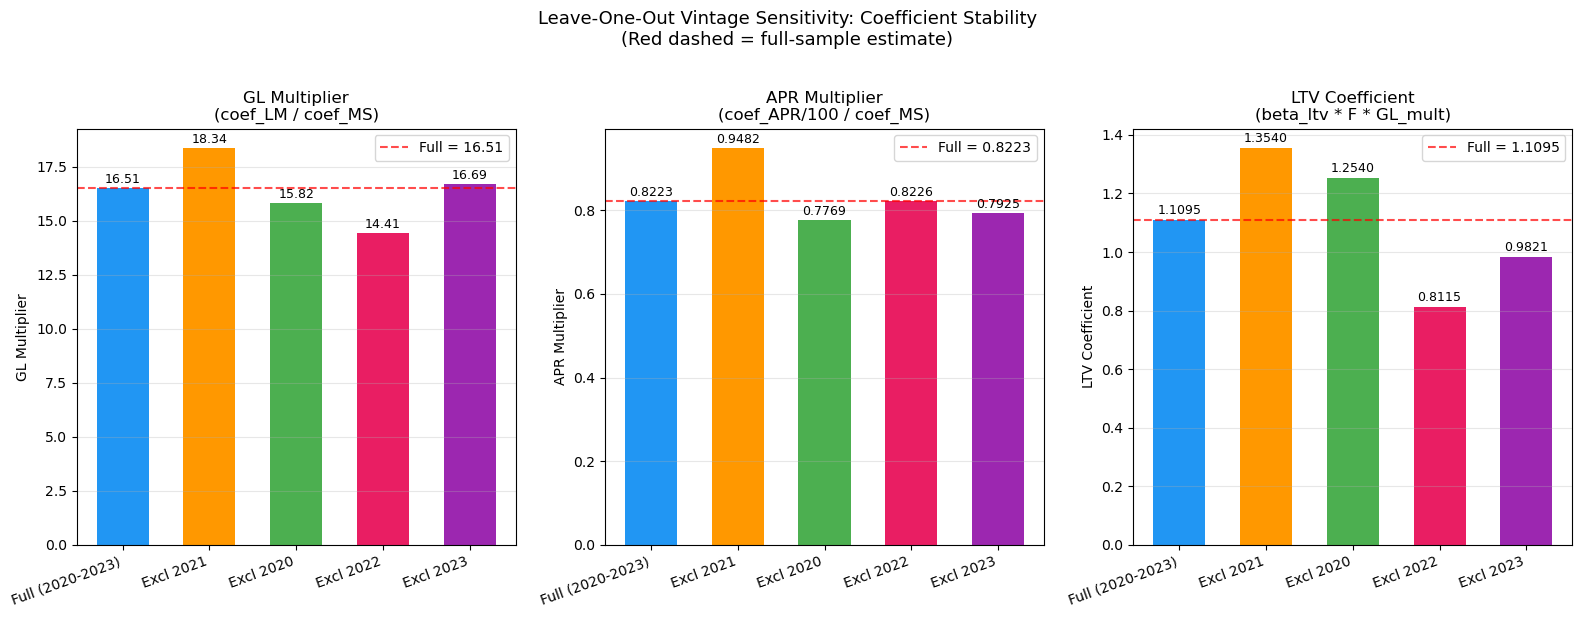

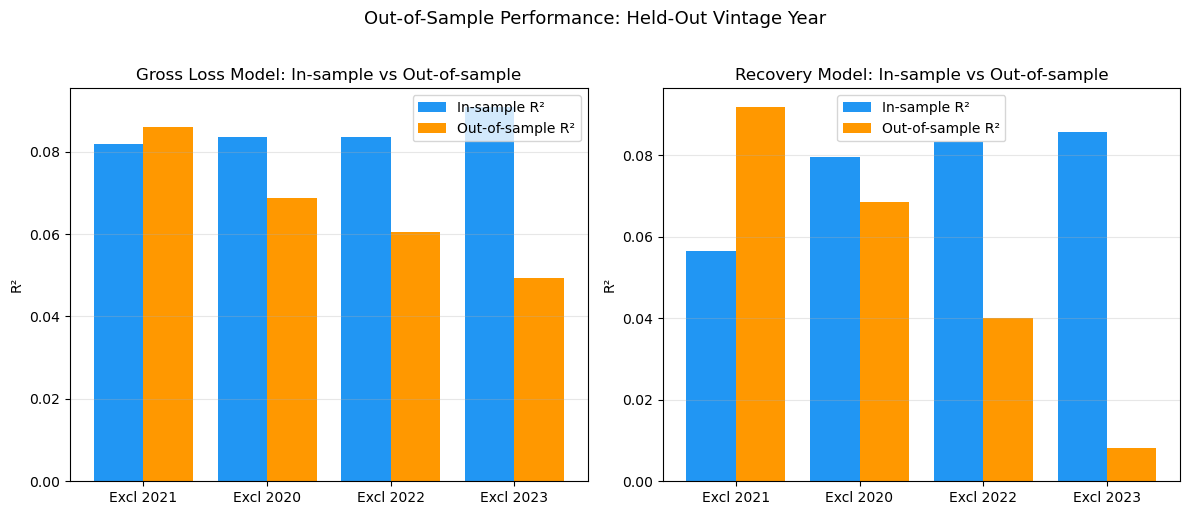

In [15]:
# =============================================================================
# CELL 6: VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

scenario_labels = results_df['label'].tolist()
x = np.arange(len(scenario_labels))
bar_width = 0.6
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

# Panel A: GL Multiplier
ax = axes[0]
vals = results_df['gl_mult'].values
ax.bar(x, vals, bar_width, color=colors)
ax.axhline(y=full_row['gl_mult'], color='red', linestyle='--', alpha=0.7, label=f"Full = {full_row['gl_mult']:.2f}")
ax.set_ylabel('GL Multiplier')
ax.set_title('GL Multiplier\n(coef_LM / coef_MS)')
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, rotation=20, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(vals):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

# Panel B: APR Multiplier
ax = axes[1]
vals = results_df['apr_mult'].values
ax.bar(x, vals, bar_width, color=colors)
ax.axhline(y=full_row['apr_mult'], color='red', linestyle='--', alpha=0.7, label=f"Full = {full_row['apr_mult']:.4f}")
ax.set_ylabel('APR Multiplier')
ax.set_title('APR Multiplier\n(coef_APR/100 / coef_MS)')
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, rotation=20, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontsize=9)

# Panel C: LTV Coefficient (combined)
ax = axes[2]
vals = results_df['ltv_coef'].values
ax.bar(x, vals, bar_width, color=colors)
ax.axhline(y=full_row['ltv_coef'], color='red', linestyle='--', alpha=0.7, label=f"Full = {full_row['ltv_coef']:.4f}")
ax.set_ylabel('LTV Coefficient')
ax.set_title('LTV Coefficient\n(beta_ltv * F * GL_mult)')
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, rotation=20, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=9)

plt.suptitle('Leave-One-Out Vintage Sensitivity: Coefficient Stability\n'
             '(Red dashed = full-sample estimate)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('vintage_sensitivity_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Out-of-sample R² comparison ---
oos_data = results_df[results_df['label'] != 'Full (2020-2023)'].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

labels_oos = oos_data['label'].tolist()
x_oos = np.arange(len(labels_oos))

ax1.bar(x_oos - 0.2, oos_data['gl_r2'].values, 0.4, label='In-sample R²', color='#2196F3')
ax1.bar(x_oos + 0.2, oos_data['oos_gl_r2'].values, 0.4, label='Out-of-sample R²', color='#FF9800')
ax1.set_ylabel('R²')
ax1.set_title('Gross Loss Model: In-sample vs Out-of-sample')
ax1.set_xticks(x_oos)
ax1.set_xticklabels(labels_oos)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(x_oos - 0.2, oos_data['rec_r2'].values, 0.4, label='In-sample R²', color='#2196F3')
ax2.bar(x_oos + 0.2, oos_data['oos_rec_r2'].values, 0.4, label='Out-of-sample R²', color='#FF9800')
ax2.set_ylabel('R²')
ax2.set_title('Recovery Model: In-sample vs Out-of-sample')
ax2.set_xticks(x_oos)
ax2.set_xticklabels(labels_oos)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Out-of-Sample Performance: Held-Out Vintage Year', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('vintage_sensitivity_oos_r2.png', dpi=150, bbox_inches='tight')
plt.show()